## 1. Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from pathlib import Path

from dataset import WaveformDataset
from model import Autoencoder

In [2]:
dim = 32
num_file_train = 22
loss_train = 'MAE'
loss_reco = 'MAE'
crop_min = 3500
crop_max = 6500

save_param = f'test_latent{dim}_{loss_train}_[{crop_min},{crop_max}]_reco_{loss_reco}'

In [13]:
std_norm  = np.load('checkpoints/std_norm.npy')
time_vector = np.load('../Picosec/file/time_vector.npy')
integrali_trigger_on = np.load('../Picosec/file/integrali_trigger_led_on.npy')
ampiezze_min_on = np.load('../Picosec/file/ampiezze_min_crop_led_on.npy')
ampiezze = ampiezze_min_on[40000:]
integrali = integrali_trigger_on[40000:]

del ampiezze_min_on,integrali_trigger_on

plt.rcParams.update({
    'font.size': 15,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
})

In [4]:
file_list_on = sorted(Path(r'D:\DAML\SPE-Run233-metallic-MM-perovskite-275-470-LED-ON').glob('*.h5'))[1:]

ds_test = WaveformDataset(file_list_on, std_norm)

Rilevati 19 file HDF5. Inizio pre-caricamento del ritaglio in RAM...
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part02.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part03.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part04.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part05.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part06.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part07.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part08.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part09.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part10.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-perovskite-275-470-LED-ON_part11.h5 (40,000 tracce)
-> Caricato : SPE-Run233-metallic-MM-pero

## 2. Model loading

In [ ]:
checkpoint = torch.load(f'checkpoints/modello_migliore_latent{dim}.pt')
modello = Autoencoder(latent_dim=dim)
modello.load_state_dict(checkpoint['pesi'])
modello.eval()      # Switch to evaluation mode (disables Dropout, BatchNorm uses running stats)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modello = modello.to(device)

print(f"Modello caricato — epoca {checkpoint['epoca']} | val_loss {checkpoint['val_loss']:.6e}")

<ipython-input-5-33efc9f34930>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'checkpoints/modello_migliore_latent{dim}.pt')


Modello caricato — epoca 59 | val_loss 6.849997e-01


In [ ]:
def get_reconstructions(dataset, modello, n=6, device='cuda'):
    indices = np.random.choice(len(dataset), n, replace=False)
    waveforms = torch.stack([dataset[i] for i in indices]).to(device)        # Fetch and stack them into a single batch tensor
    
    with torch.no_grad():       # No gradient tracking needed, this is inference only
        ricostruite, _ = modello(waveforms)     # Forward pass; discard the latent vector here
    
    return waveforms.cpu().numpy(), ricostruite.cpu().numpy(), indices      # Move back to CPU/numpy for plotting

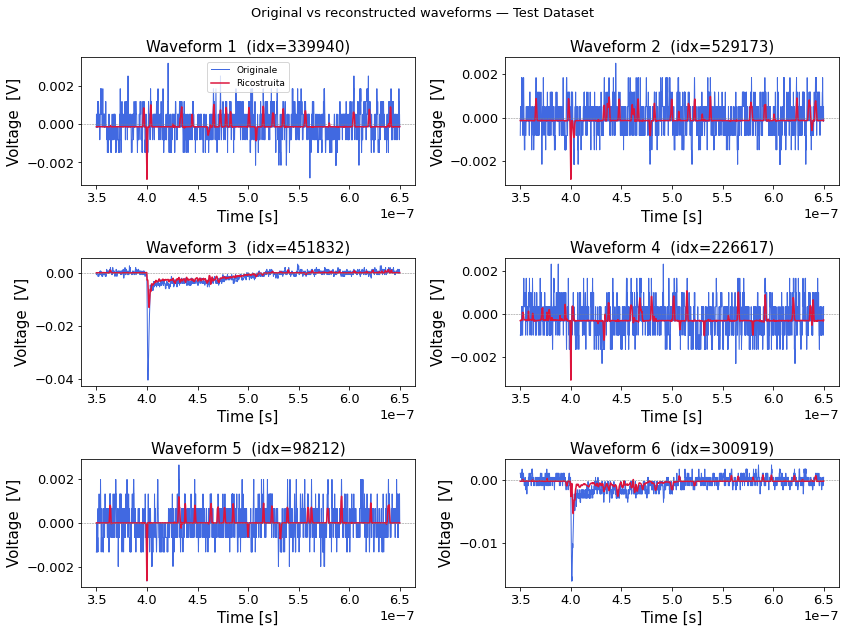

In [7]:
wf_orig_on, wf_reco_on, idx_on = get_reconstructions(ds_test,  modello, n=6, device=device)

wf_orig_volt_on = wf_orig_on * std_norm 
wf_reco_volt_on = wf_reco_on * std_norm 

fig, assi = plt.subplots(3, 2, figsize=(12, 9))
assi = assi.flatten()

for i in range(6):
    ax = assi[i]
    ax.plot(time_vector[0, crop_min:crop_max], wf_orig_volt_on[i], lw=1, color='royalblue', label='Originale')
    ax.plot(time_vector[0, crop_min:crop_max], wf_reco_volt_on[i], lw=1.5, color='crimson', ls='-', label='Ricostruita')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage  [V]')
    ax.set_title(f'Waveform {i+1}  (idx={idx_on[i]})')
    if i == 0:
        ax.legend(fontsize=9)

fig.suptitle('Original vs reconstructed waveforms — Test Dataset', fontsize=13)
fig.tight_layout()
plt.savefig(f'../Picosec/outputs/wf_orig_vs_reco_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [8]:
print(f"Media wf originali:    {wf_orig_volt_on.mean():.6f}")
print(f"Media wf ricostruite:  {wf_reco_volt_on.mean():.6f}")

Media wf originali:    -0.000339
Media wf ricostruite:  -0.000281


## 3. Reconstruction error (anomaly score)

In [9]:
def calcola_errori(modello, loader, device, std_norm, etichetta=""):
    modello.eval()
    errori = []
    n_batch = len(loader)
    std = torch.tensor(std_norm, dtype=torch.float32).to(device)
    for i, wf in enumerate(loader):
        wf = wf.to(device)
        with torch.no_grad():
            err = modello.reconstruction_error_mae(wf)
        errori.append(err.cpu().numpy())
        if (i+1) % 50 == 0 or (i+1) == n_batch:
            print(f"  {etichetta}: batch {i+1}/{n_batch}", end="\r")
    print()
    return np.concatenate(errori)

In [10]:
loader_test = DataLoader(ds_test, batch_size=512, shuffle=False, num_workers=0)
err_test = calcola_errori(modello, loader_test, device, float(std_norm), "LED on")
print(err_test)


  LED on: batch 1483/1483
[1.8726679  0.63742393 0.6508877  ... 0.65113384 0.66236836 0.70928085]


## 4. Threshold selection

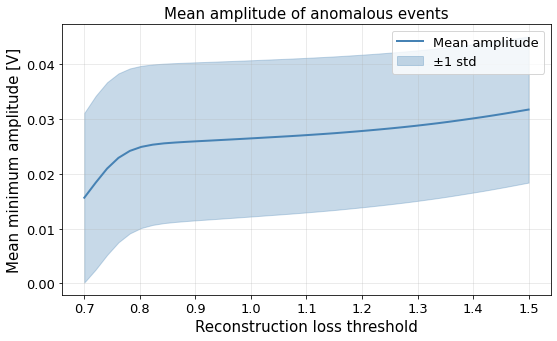

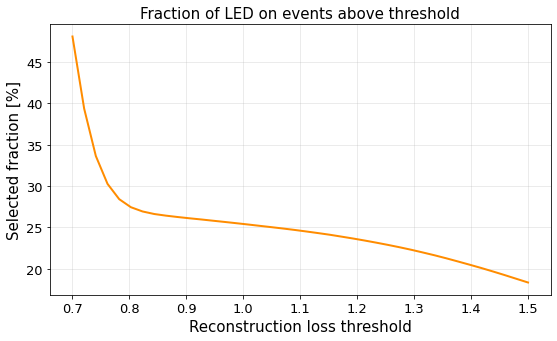

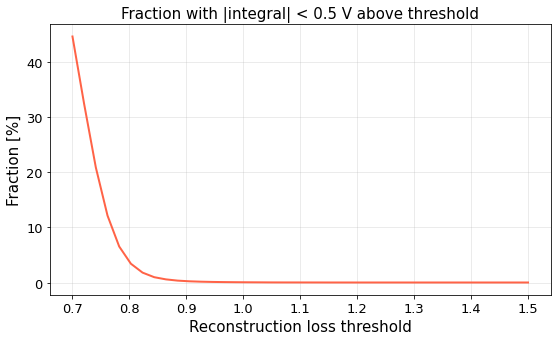

In [ ]:
soglie = np.linspace(0.7, 1.5, 40)
medie         = []
std_list      = []
purezza       = []
fraz_int_zero = []

for soglia in soglie:
    mask    = err_test > soglia
    n_sopra = mask.sum()

    if n_sopra > 0:
        medie.append(-ampiezze[mask].mean())
        std_list.append(-ampiezze[mask].std())
        fraz_int_zero.append((np.abs(integrali[mask]) < 0.5).sum() / n_sopra)
    else:
        medie.append(np.nan)
        std_list.append(np.nan)
        fraz_int_zero.append(np.nan)

    purezza.append(n_sopra / len(err_test))

medie         = np.array(medie)
std_list      = np.array(std_list)
purezza       = np.array(purezza)
fraz_int_zero = np.array(fraz_int_zero)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(soglie, medie, color='steelblue', lw=2, label='Mean amplitude')
ax.fill_between(soglie, medie - std_list, medie + std_list, alpha=0.3, color='steelblue', label='±1 std')
ax.set_xlabel('Reconstruction loss threshold')
ax.set_ylabel('Mean minimum amplitude [V]')
ax.set_title('Mean amplitude of anomalous events')
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
plt.savefig(f'../Picosec/outputs/scan_soglie_ampiezza_{save_param}.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(soglie, purezza * 100, color='darkorange', lw=2)
ax.set_xlabel('Reconstruction loss threshold')
ax.set_ylabel('Selected fraction [%]')
ax.set_title('Fraction of LED on events above threshold')
ax.grid(alpha=0.3)

fig.tight_layout()
plt.savefig(f'../Picosec/outputs/scan_soglie_frazione_{save_param}.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(soglie, fraz_int_zero * 100, color='tomato', lw=2)
ax.set_xlabel('Reconstruction loss threshold')
ax.set_ylabel('Fraction [%]')
ax.set_title('Fraction with |integral| < 0.5 V above threshold')
ax.grid(alpha=0.3)

fig.tight_layout()
plt.savefig(f'../Picosec/outputs/scan_soglie_integrale_{save_param}.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

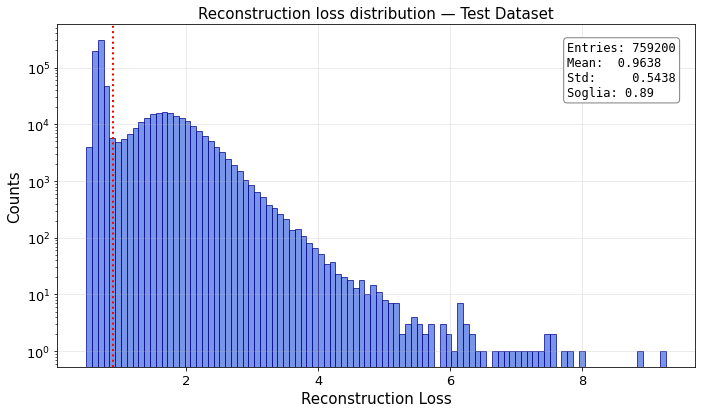

In [32]:
soglia = 0.89

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(err_test, bins=100, color='royalblue', alpha=0.7, edgecolor='darkblue')
ax.axvline(soglia, color='red', lw=2, ls=':')  
ax.set_xlabel("Reconstruction Loss")
ax.set_ylabel("Counts")
ax.set_title("Reconstruction loss distribution — Test Dataset")
ax.set_yscale('log')
ax.grid(alpha=0.3)

stats_text = (f"Entries: {len(err_test)}\n"
              f"Mean:  {err_test.mean():.4f}\n"
              f"Std:     {err_test.std():.4f}\n"
              f"Soglia: {soglia}")

ax.text(0.80, 0.95, stats_text, transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=1), fontfamily='monospace')


fig.tight_layout()
plt.savefig(f'../Picosec/outputs/Distribuzione_errore_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Physical features: amplitude and integral spectra

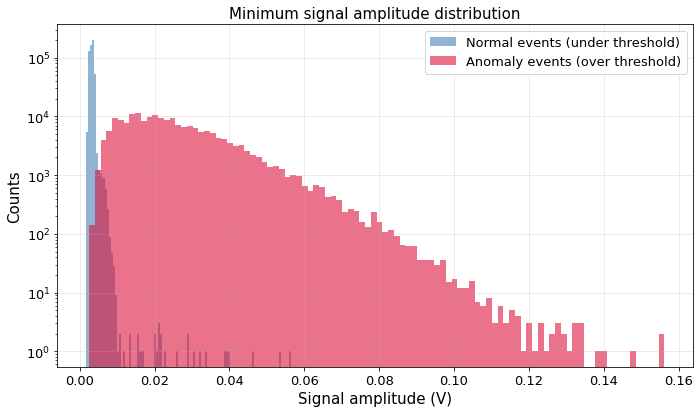

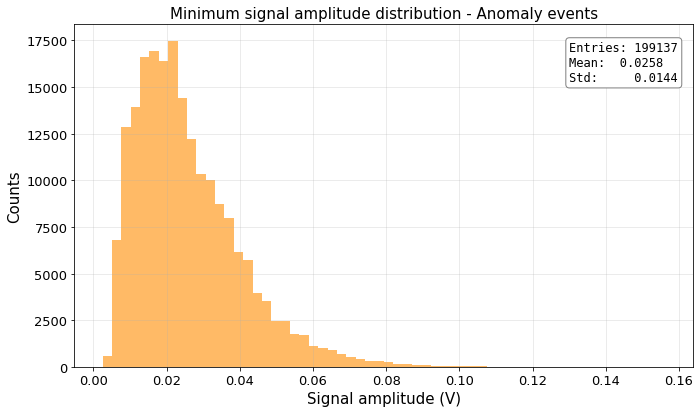

Soglia applicata: 0.89
Numero anomalie: 199137
Media anomalie: 0.0258
Std anomalie: 0.0144


In [33]:
mask_segnale = err_test > soglia

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(-ampiezze[~mask_segnale], bins=100, color='steelblue', alpha=0.6, label='Normal events (under threshold)')
ax.hist(-ampiezze[mask_segnale],  bins=100, color='crimson', alpha=0.6, label='Anomaly events (over threshold)')
ax.set_xlabel("Signal amplitude (V)")
ax.set_ylabel("Counts")
ax.set_title("Minimum signal amplitude distribution")
ax.legend()
ax.set_yscale("log")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.savefig(f'../Picosec/outputs/Distribuzione_ampiezze_confronto_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(-ampiezze[mask_segnale], bins=60, alpha=0.6, label="LED on — anomalia (sopra soglia)",  color="darkorange")
ax.set_xlabel("Signal amplitude (V)")
ax.set_ylabel("Counts")
ax.set_title("Minimum signal amplitude distribution - Anomaly events")
ax.grid(alpha=0.3)

stats_text = (f"Entries: {len(-ampiezze[mask_segnale])}\n"
              f"Mean:  {-ampiezze[mask_segnale].mean():.4f}\n"
              f"Std:     {ampiezze[mask_segnale].std():.4f}")

ax.text(0.80, 0.95, stats_text, transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=1), fontfamily='monospace')


fig.tight_layout()
plt.savefig(f'../Picosec/outputs/Distribuzione_ampiezze_taglio_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Soglia applicata: {soglia}')
print(f'Numero anomalie: {len(ampiezze[mask_segnale])}')
print(f'Media anomalie: {-ampiezze[mask_segnale].mean():.4f}')
print(f'Std anomalie: {ampiezze[mask_segnale].std():.4f}')

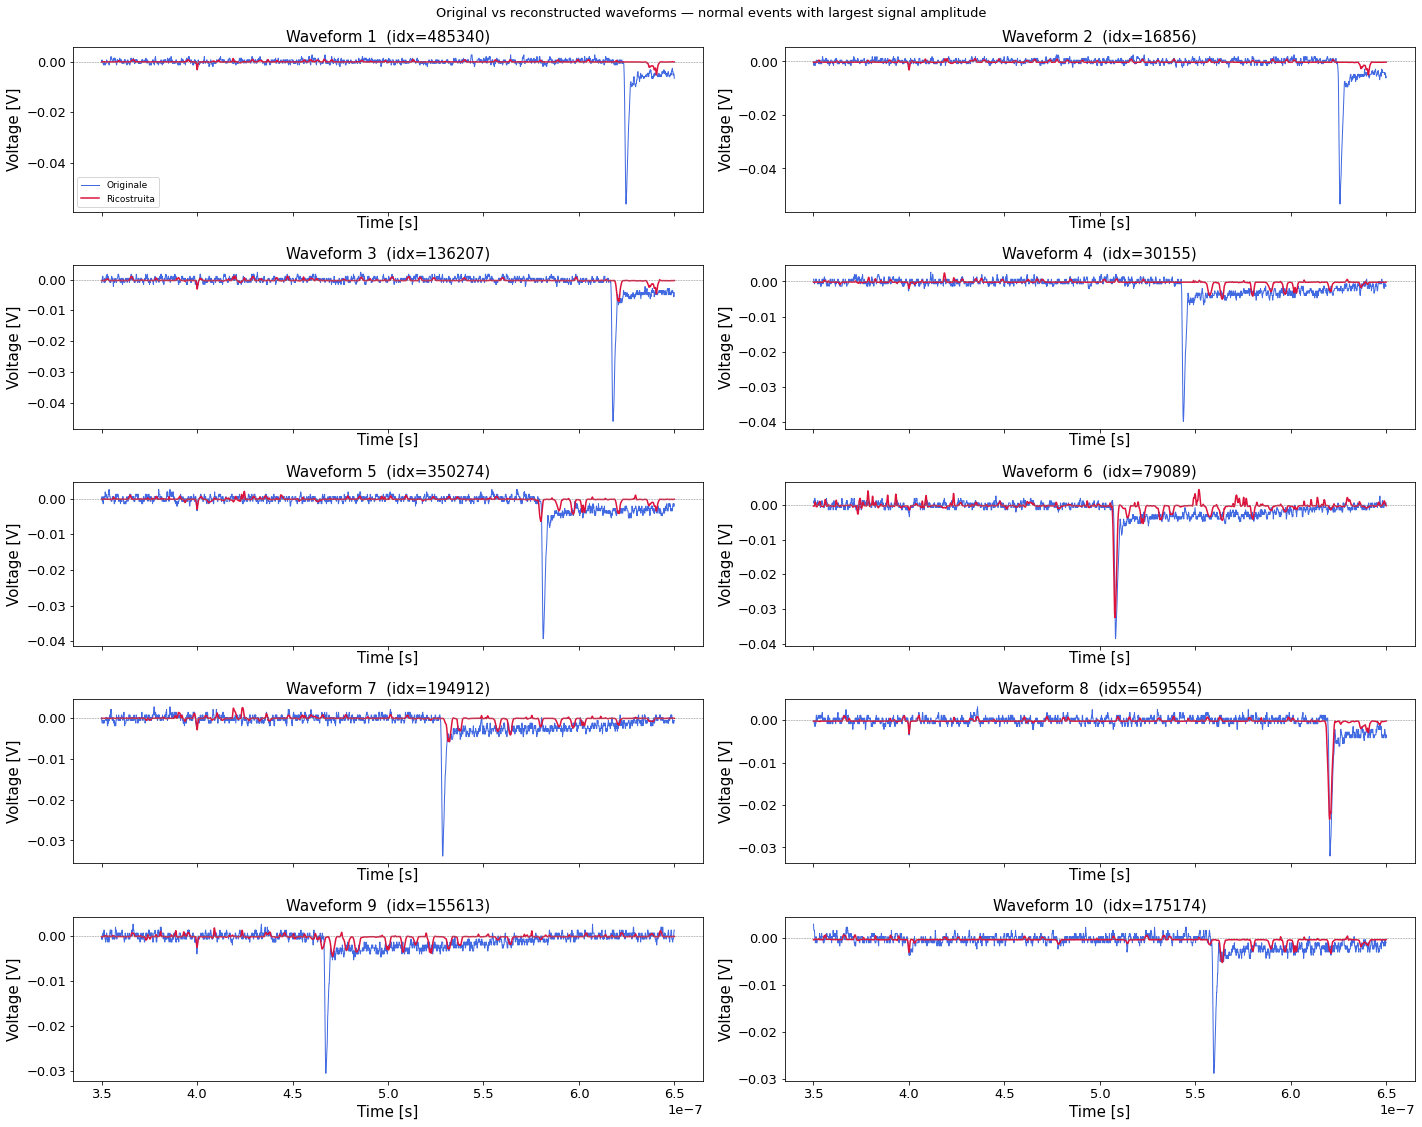

In [34]:
idx_non_anomali = np.where(~mask_segnale)[0] 
ampiezze_non_anomale = -ampiezze[~mask_segnale]

indici_ordinati = np.argsort(ampiezze_non_anomale)[::-1]
top10_idx = idx_non_anomali[indici_ordinati[:10]] 

waveforms = torch.stack([ds_test[i] for i in top10_idx]).to(device)

with torch.no_grad():
    ricostruite, _ = modello(waveforms)

wf_orig_non_anomalie = waveforms.cpu().numpy()
wf_reco_non_anomalie  = ricostruite.cpu().numpy()

wf_orig_volt_off_non_anomalie = wf_orig_non_anomalie * std_norm 
wf_reco_volt_off_non_anomalie = wf_reco_non_anomalie * std_norm 

fig, axes = plt.subplots(5, 2, figsize=(20, 16), sharex=True)
assi = axes.flatten()

for i in range(10):
    ax = assi[i]
    ax.plot(time_vector[0, crop_min:crop_max], wf_orig_volt_off_non_anomalie[i], lw=1, color='royalblue', label='Originale')
    ax.plot(time_vector[0, crop_min:crop_max], wf_reco_volt_off_non_anomalie[i], lw=1.5, color='crimson', ls='-', label='Ricostruita')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage [V]')
    ax.set_title(f'Waveform {i+1}  (idx={top10_idx[i]})')
    if i == 0:
        ax.legend(fontsize=9)

fig.suptitle('Original vs reconstructed waveforms — normal events with largest signal amplitude', fontsize=13)
fig.tight_layout()
plt.savefig(f'../Picosec/outputs/wf_orig_vs_reco_taglio_ultime10_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

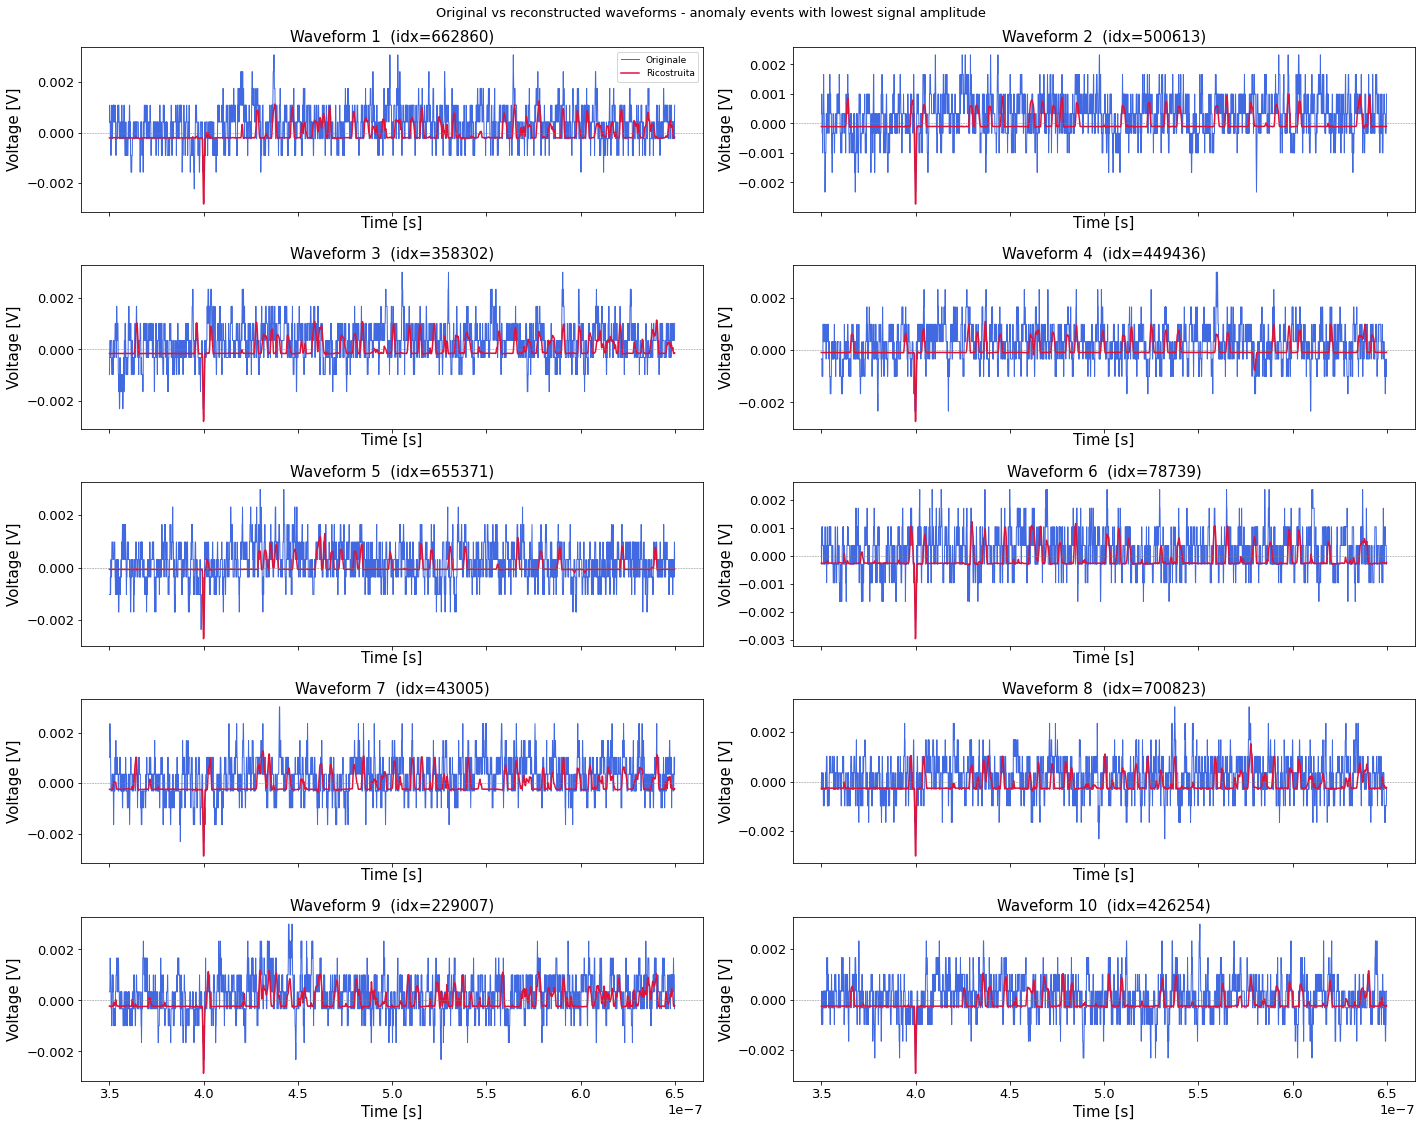

In [35]:
idx_anomali = np.where(mask_segnale)[0] 
ampiezze_anomale = -ampiezze[mask_segnale]

indici_ordinati_anomali = np.argsort(ampiezze_anomale)[::-1]
top10_idx_anomali = idx_anomali[indici_ordinati_anomali[-10:]] 

waveforms = torch.stack([ds_test[i] for i in top10_idx_anomali]).to(device)

with torch.no_grad():
    ricostruite, _ = modello(waveforms)

wf_orig_anomalie = waveforms.cpu().numpy()
wf_reco_anomalie  = ricostruite.cpu().numpy()

wf_orig_volt_on_anomalie = wf_orig_anomalie * std_norm 
wf_reco_volt_on_anomalie = wf_reco_anomalie * std_norm 

fig, axes = plt.subplots(5, 2, figsize=(20, 16), sharex=True)
assi = axes.flatten()

for i in range(10):
    ax = assi[i]
    ax.plot(time_vector[0, crop_min:crop_max], wf_orig_volt_on_anomalie[i], lw=1, color='royalblue', label='Originale')
    ax.plot(time_vector[0, crop_min:crop_max], wf_reco_volt_on_anomalie[i], lw=1.5, color='crimson', ls='-', label='Ricostruita')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('Time [s]')
    ax.set_ylabel('Voltage [V]')
    ax.set_title(f'Waveform {i+1}  (idx={top10_idx_anomali[i]})')
    if i == 0:
        ax.legend(fontsize=9)

fig.suptitle('Original vs reconstructed waveforms - anomaly events with lowest signal amplitude', fontsize=13)
fig.tight_layout()
plt.savefig(f'../Picosec/outputs/wf_orig_vs_reco_taglio_prime10_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

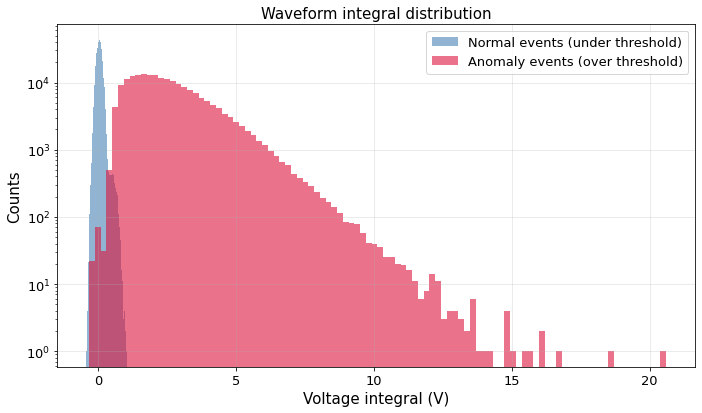

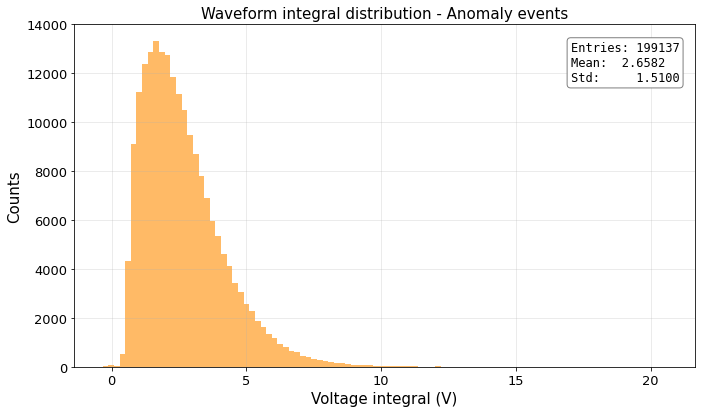

Soglia applicata: 0.89
Numero anomalie: 199137
Media anomalie: 2.6582
Std anomalie: 1.5100


In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(-integrali[~mask_segnale], bins=100, color='steelblue', alpha=0.6, label='Normal events (under threshold)')
ax.hist(-integrali[mask_segnale],  bins=100, color='crimson', alpha=0.6, label='Anomaly events (over threshold)')
ax.set_xlabel("Voltage integral (V)")
ax.set_ylabel("Counts")
ax.set_title("Waveform integral distribution")
ax.legend()
ax.set_yscale("log")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.savefig(f'../Picosec/outputs/Distribuzione_integrali_confronto_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(-integrali[mask_segnale], bins=100, alpha=0.6, label="LED on — anomalia (sopra soglia)",  color="darkorange")
ax.set_xlabel("Voltage integral (V)")
ax.set_ylabel("Counts")
ax.set_title("Waveform integral distribution - Anomaly events")
ax.grid(alpha=0.3)

stats_text = (f"Entries: {len(-integrali[mask_segnale])}\n"
              f"Mean:  {-integrali[mask_segnale].mean():.4f}\n"
              f"Std:     {integrali[mask_segnale].std():.4f}")

ax.text(0.80, 0.95, stats_text, transform=ax.transAxes, fontsize=12, verticalalignment='top', horizontalalignment='left', bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=1), fontfamily='monospace')


fig.tight_layout()
plt.savefig(f'../Picosec/outputs/Distribuzione_integrali_taglio_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Soglia applicata: {soglia}')
print(f'Numero anomalie: {len(integrali[mask_segnale])}')
print(f'Media anomalie: {-integrali[mask_segnale].mean():.4f}')
print(f'Std anomalie: {integrali[mask_segnale].std():.4f}')

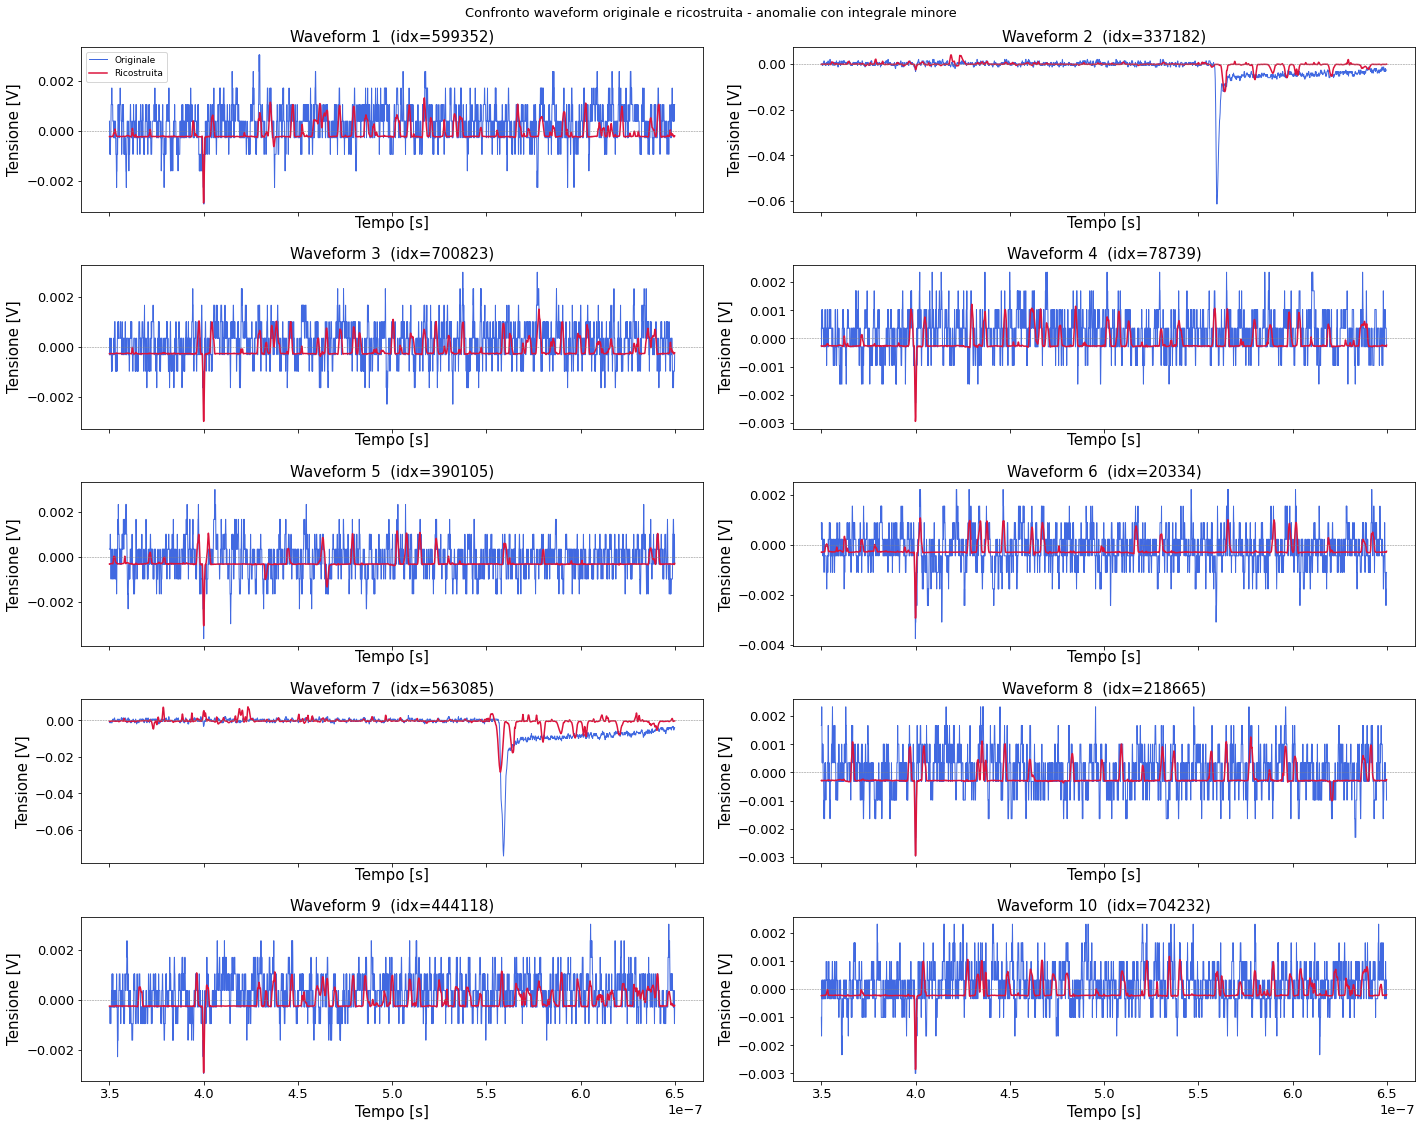

In [20]:
integrali_anomali_int = np.abs(integrali[mask_segnale])  # valore assoluto
indici_ordinati_anomali_int = np.argsort(integrali_anomali_int)  # crescente
top10_idx_anomali_int = idx_anomali[indici_ordinati_anomali_int[:10]]  # i 10 più piccoli in valore assoluto

waveforms = torch.stack([ds_test[i] for i in top10_idx_anomali_int]).to(device)

with torch.no_grad():
    ricostruite, _ = modello(waveforms)

wf_orig_anomalie = waveforms.cpu().numpy()
wf_reco_anomalie  = ricostruite.cpu().numpy()

wf_orig_volt_on_anomalie = wf_orig_anomalie * std_norm 
wf_reco_volt_on_anomalie = wf_reco_anomalie * std_norm 

fig, axes = plt.subplots(5, 2, figsize=(20, 16), sharex=True)
assi = axes.flatten()

for i in range(10):
    ax = assi[i]
    ax.plot(time_vector[0, crop_min:crop_max], wf_orig_volt_on_anomalie[i], lw=1, color='royalblue', label='Originale')
    ax.plot(time_vector[0, crop_min:crop_max], wf_reco_volt_on_anomalie[i], lw=1.5, color='crimson', ls='-', label='Ricostruita')
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel('Tensione [V]')
    ax.set_title(f'Waveform {i+1}  (idx={top10_idx_anomali_int[i]})')
    if i == 0:
        ax.legend(fontsize=9)

fig.suptitle('Confronto waveform originale e ricostruita - anomalie con integrale minore', fontsize=13)
fig.tight_layout()
plt.savefig(f'../Picosec/outputs/wf_orig_vs_reco_taglio_prime10_integrale_{save_param}.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

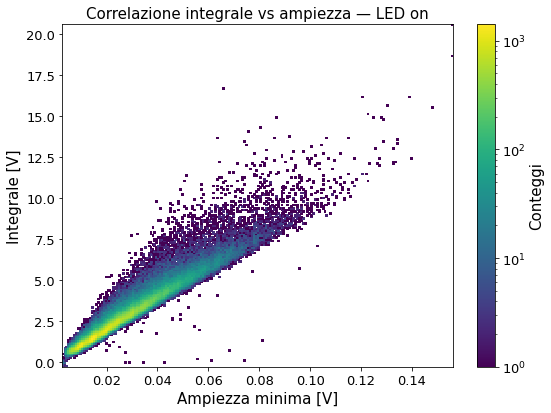

In [21]:
#HEATMAP AMPIEZZA VS INTEGRALE
import matplotlib

fig, ax = plt.subplots(figsize=(8, 6))

h = ax.hist2d(-ampiezze[mask_segnale], -integrali[mask_segnale], bins=200, cmap='viridis',norm=matplotlib.colors.LogNorm())

plt.colorbar(h[3], ax=ax, label='Conteggi')

ax.set_ylabel('Integrale [V]')
ax.set_xlabel('Ampiezza minima [V]')
ax.set_title('Correlazione integrale vs ampiezza — LED on')

plt.tight_layout()
plt.savefig(f'../Picosec/outputs/correlazione_ampiezza_integrale_taglio_{save_param}.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

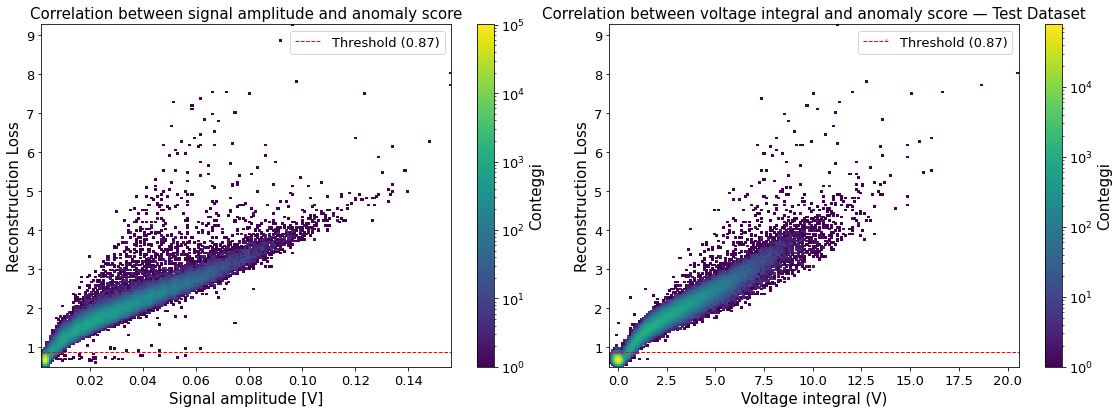

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

h1 = axes[0].hist2d(-ampiezze, err_test[:], bins=200, cmap='viridis',norm=matplotlib.colors.LogNorm())
plt.colorbar(h1[3], ax=axes[0], label='Conteggi')
axes[0].axhline(0.87, color='red', lw=1, ls='--', label=f'Threshold (0.87)')
axes[0].set_xlabel('Signal amplitude [V]')
axes[0].set_ylabel(f'Reconstruction Loss')
axes[0].set_title('Correlation between signal amplitude and anomaly score')
axes[0].legend()

h2 = axes[1].hist2d(-integrali, err_test[:], bins=200, cmap='viridis',norm=matplotlib.colors.LogNorm())
plt.colorbar(h2[3], ax=axes[1], label='Conteggi')
axes[1].axhline(0.87, color='red', lw=1, ls='--', label=f'Threshold (0.87)')
axes[1].set_xlabel('Voltage integral (V)')
axes[1].set_ylabel(f'Reconstruction Loss')
axes[1].set_title('Correlation between voltage integral and anomaly score — Test Dataset')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'../Picosec/outputs/correlazioni_loss_{save_param}.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Latent space visualization (PCA)

In [24]:
from sklearn.decomposition import PCA

def estrai_latenti(modello, loader, device):
    modello.eval()
    latenti = []
    for wf in loader:
        wf = wf.to(device)
        z = modello.encode(wf)
        latenti.append(z.detach().cpu().numpy())
    return np.concatenate(latenti)

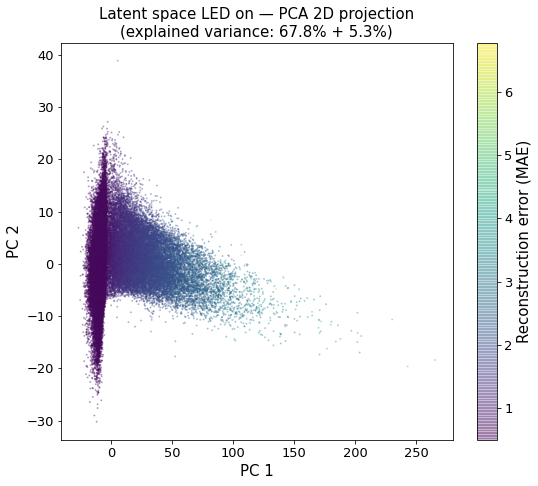

In [25]:
N = 100_000
loader_segnale_sub  = DataLoader(torch.utils.data.Subset(ds_test,  range(N)), batch_size=512, shuffle=False)

z_segnale = estrai_latenti(modello, loader_segnale_sub, device)

reducer = PCA(n_components=2, random_state=42)
z_2d = reducer.fit_transform(z_segnale)

fig, ax = plt.subplots(figsize=(8, 7))

sc = ax.scatter(z_2d[:, 0], z_2d[:, 1], s=1, alpha=0.3, c=err_test[:N], cmap='viridis')
plt.colorbar(sc, ax=ax, label='Reconstruction error (MAE)')
var = reducer.explained_variance_ratio_
ax.set_title(f'Latent space LED on — PCA 2D projection\n(explained variance: {var[0]:.1%} + {var[1]:.1%})')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')

fig.tight_layout()
plt.savefig(f'../Picosec/outputs/spazio_latente_{save_param}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Polya distribution fit

In [26]:
from lmfit import Model
from scipy.special import gamma

def polya(x, b, x_mean, A):
    return A * (1+b)**(1+b) / gamma(1+b) * (x/x_mean)**b * np.exp(-(1+b)*x/x_mean) / x_mean

c:\Users\ozner\anaconda3\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[[Model]]
    Model(polya)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 29
    # data points      = 59
    # variables        = 3
    chi-square         = 1184.29797
    reduced chi-square = 21.1481781
    Akaike info crit   = 182.962712
    Bayesian info crit = 189.195325
    R-squared          = 0.99360229
[[Variables]]
    b:       2.14644835 +/- 0.05500758 (2.56%) (init = 1)
    x_mean:  0.02547219 +/- 1.5350e-04 (0.60%) (init = 0.025878)
    A:       514.238250 +/- 5.36158112 (1.04%) (init = 17489)
[[Correlations]] (unreported correlations are < 0.100)
    C(b, x_mean) = +0.1191
    C(b, A)      = -0.1057


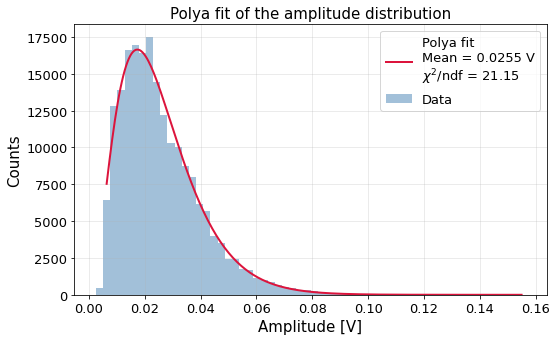

In [27]:
data_amp = -ampiezze[mask_segnale]

counts_amp, bin_edges_amp = np.histogram(data_amp, bins=60, density=False)
bin_centers_amp = (bin_edges_amp[:-1] + bin_edges_amp[1:]) / 2

model = Model(polya)
params = model.make_params(b=1.0, x_mean=data_amp.mean(), A=counts_amp.max())
params['b'].set(min=0)
params['x_mean'].set(min=0)

errors_amp = np.sqrt(np.maximum(counts_amp, 1))

soglia_amp = 0.004
mask_fit_amp = bin_centers_amp > soglia_amp
result_amp = model.fit(counts_amp[mask_fit_amp], params, x=bin_centers_amp[mask_fit_amp],
                        weights=1/errors_amp[mask_fit_amp])
print(result_amp.fit_report())

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(bin_centers_amp, counts_amp, width=np.diff(bin_edges_amp), alpha=0.5, color='steelblue', label='Data')

x_fit = np.linspace(bin_centers_amp[mask_fit_amp].min(), bin_centers_amp[mask_fit_amp].max(), 300)
y_fit = result_amp.eval(x=x_fit)

chi2_ndf_amp = result_amp.redchi
ax.plot(x_fit, y_fit, color='crimson', lw=2, label=f'Polya fit\nMean = {result_amp.params["x_mean"].value:.4f} V\n$\\chi^2$/ndf = {chi2_ndf_amp:.2f}')

ax.set_xlabel('Amplitude [V]')
ax.set_ylabel('Counts')
ax.set_title('Polya fit of the amplitude distribution')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Picosec/outputs/polya_fit_amplitude.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

c:\Users\ozner\anaconda3\lib\site-packages\uncertainties\core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


[[Model]]
    Model(polya)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 33
    # data points      = 96
    # variables        = 3
    chi-square         = 807.595219
    reduced chi-square = 8.68381956
    Akaike info crit   = 210.452426
    Bayesian info crit = 218.145471
    R-squared          = 0.99640089
[[Variables]]
    b:       2.06772508 +/- 0.03427798 (1.66%) (init = 1)
    x_mean:  5.25543929 +/- 0.02056964 (0.39%) (init = 5.328271)
    A:       84148.3423 +/- 562.212817 (0.67%) (init = 13229)
[[Correlations]] (unreported correlations are < 0.100)
    C(b, x_mean) = +0.1223
    C(b, A)      = -0.1099


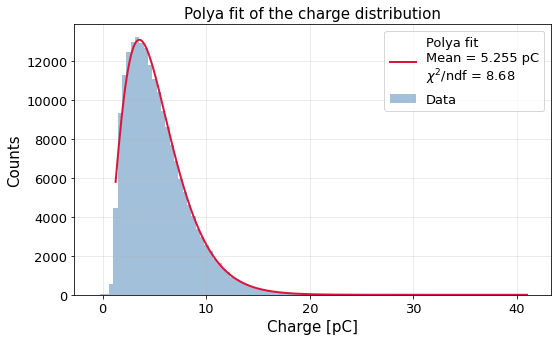

In [31]:
dt = time_vector[0,3551] - time_vector[0,3550]
data_int = -integrali[mask_segnale] * dt / 50 

scala = 1e12  # porta a pC
data_int_scaled = data_int * scala

counts, bin_edges = np.histogram(data_int_scaled, bins=100, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

model = Model(polya)
params = model.make_params(b=1.0, x_mean=data_int_scaled.mean(), A=counts.max())
params['b'].set(min=0)
params['x_mean'].set(min=0)

errors = np.sqrt(np.maximum(counts, 1))  # errori di Poisson

mask_fit = bin_centers > 1  # soglia nella scala pC
result = model.fit(counts[mask_fit], params, x=bin_centers[mask_fit],
                    weights=1/errors[mask_fit])
print(result.fit_report())

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(bin_centers, counts, width=np.diff(bin_edges), alpha=0.5, color='steelblue', label='Data')

x_fit = np.linspace(bin_centers[mask_fit].min(), bin_centers[mask_fit].max(), 300)
y_fit = result.eval(x=x_fit)

b_fit      = result.params['b'].value
x_mean_fit = result.params['x_mean'].value
chi2_ndf   = result.redchi

label_fit = (f'Polya fit\n'
             f'Mean = {x_mean_fit:.3f} pC\n'
             f'$\\chi^2$/ndf = {chi2_ndf:.2f}')

ax.plot(x_fit, y_fit, color='crimson', lw=2, label=label_fit)

ax.set_xlabel('Charge [pC]')
ax.set_ylabel('Counts')
ax.set_title('Polya fit of the charge distribution')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Picosec/outputs/polya_fit_charge.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()